In [2]:
import numpy as np
import pandas as pd
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import time, gc

root = 'C:/Users/abhay/Minor_Project/Dataset'

orders = pd.read_csv(root + '/orders.csv')
order_products_prior = pd.read_csv(root + '/order_products__prior.csv')
order_products_train = pd.read_csv(root + '/order_products__train.csv')
products = pd.read_csv(root + '/products.csv')

order_products = pd.concat([order_products_prior, order_products_train])

print("Original:", order_products.shape)

# -----------------------------------------------------
# STEP 1 — USE ONLY TOP-N PRODUCTS (hard requirement)
# -----------------------------------------------------

TOP_N_PRODUCTS = 5000    # you can increase to 8000 safely

top_products = (
    order_products['product_id']
    .value_counts()
    .head(TOP_N_PRODUCTS)
    .index
)

order_products_small = order_products[
    order_products['product_id'].isin(top_products)
]

print("After product filtering:", order_products_small.shape)

# -----------------------------------------------------
# STEP 2 — USE ONLY 10% OF ORDERS
# -----------------------------------------------------

sample_orders = (
    orders['order_id']
    .drop_duplicates()
    .sample(frac=0.10, random_state=42)
)

order_products_small = order_products_small[
    order_products_small['order_id'].isin(sample_orders)
]

print("After sampling 10%:", order_products_small.shape)

# -----------------------------------------------------
# STEP 3 — MAKE BASKETS (transactions)
# -----------------------------------------------------

basket = (
    order_products_small
    .groupby('order_id')['product_id']
    .apply(list)
    .reset_index()
)

print("Basket size:", basket.shape)

# -----------------------------------------------------
# STEP 4 — TRANSACTION ENCODER (will NOT exceed 5000 columns)
# -----------------------------------------------------

te = TransactionEncoder()

te_ary = te.fit(basket['product_id']).transform(basket['product_id'])

df_tf = pd.DataFrame(te_ary, columns=te.columns_)
print("Final matrix shape:", df_tf.shape)

# required fix
df_tf.columns = df_tf.columns.astype(str)

# -----------------------------------------------------
# STEP 5 — RUN APRIORI + FP-GROWTH SAFELY
# -----------------------------------------------------

def run_apriori(df, min_sup):
    start = time.time()
    it = apriori(df, min_support=min_sup, use_colnames=True, low_memory=True)
    rules = association_rules(it, metric="lift", min_threshold=1)
    return it, rules, time.time() - start

def run_fp(df, min_sup):
    start = time.time()
    it = fpgrowth(df, min_support=min_sup, use_colnames=True, max_len=3)
    rules = association_rules(it, metric="lift", min_threshold=1)
    return it, rules, time.time() - start

supports = [0.01, 0.005, 0.003]

results = []

for sup in supports:
    print("\n===== SUPPORT:", sup, "=====")

    ap_it, ap_rules, ap_time = run_apriori(df_tf, sup)
    print("Apriori:", len(ap_it), "itemsets |", len(ap_rules),"rules | time =", ap_time)

    fp_it, fp_rules, fp_time = run_fp(df_tf, sup)
    print("FP-growth:", len(fp_it), "itemsets |", len(fp_rules), "rules | time =", fp_time)

    results.append([sup, len(ap_it), len(ap_rules), len(fp_it), len(fp_rules), ap_time, fp_time])

df_compare = pd.DataFrame(results, columns=[
    "support", "apriori_itemsets", "apriori_rules", "fpgrowth_itemsets", "fpgrowth_rules",
    "apriori_time", "fpgrowth_time"
])

df_compare


Original: (33819106, 4)
After product filtering: (27549518, 4)
After sampling 10%: (2760418, 4)
Basket size: (328665, 2)
Final matrix shape: (328665, 5000)

===== SUPPORT: 0.01 =====
Apriori: 123 itemsets | 32 rules | time = 2.7259747982025146
FP-growth: 123 itemsets | 32 rules | time = 142.85567927360535

===== SUPPORT: 0.005 =====
Apriori: 336 itemsets | 154 rules | time = 4.249563455581665
FP-growth: 336 itemsets | 154 rules | time = 380.2029492855072

===== SUPPORT: 0.003 =====
Apriori: 812 itemsets | 598 rules | time = 7.072934865951538
FP-growth: 812 itemsets | 598 rules | time = 321.8166718482971


,support,apriori_itemsets,apriori_rules,fpgrowth_itemsets,fpgrowth_rules,apriori_time,fpgrowth_time
0,0.010,123,32,123,32,2.725975,142.855679
1,0.005,336,154,336,154,4.249563,380.202949
2,0.003,812,598,812,598,7.072935,321.816672


In [3]:
# df_compare.to_csv("df_compare.csv", index=False)

In [25]:
ap_it

,support,itemsets
0,0.005973,(45)
1,0.011413,(196)
2,0.007829,(260)
3,0.004841,(329)
4,0.009712,(432)
...,...,...
807,0.003755,"(13176, 21137, 27966)"
808,0.004798,"(13176, 47209, 21137)"
809,0.003825,"(13176, 47209, 21903)"
810,0.003712,"(13176, 47209, 27966)"


In [23]:
ap_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(4605),(21903),0.023948,0.076528,0.003265,0.136323,1.781356,1.0,0.001432,1.069234,0.449392,0.033584,0.064751,0.089492
1,(21903),(4605),0.076528,0.023948,0.003265,0.042661,1.781356,1.0,0.001432,1.019546,0.474979,0.033584,0.019171,0.089492
2,(4605),(24852),0.023948,0.149928,0.006828,0.285097,1.901564,1.0,0.003237,1.189074,0.485750,0.040872,0.159009,0.165318
3,(24852),(4605),0.149928,0.023948,0.006828,0.045539,1.901564,1.0,0.003237,1.022621,0.557737,0.040872,0.022121,0.165318
4,(4605),(26209),0.023948,0.044720,0.003046,0.127176,2.843802,1.0,0.001975,1.094470,0.664266,0.046411,0.086315,0.097640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,"(24852, 47766)",(21903),0.017017,0.076528,0.003335,0.195959,2.560629,1.0,0.002032,1.148539,0.620022,0.036966,0.129329,0.119767
594,"(21903, 47766)",(24852),0.009885,0.149928,0.003335,0.337335,2.249981,1.0,0.001853,1.282808,0.561099,0.021311,0.220460,0.179788
595,(24852),"(21903, 47766)",0.149928,0.009885,0.003335,0.022242,2.249981,1.0,0.001853,1.012638,0.653535,0.021311,0.012480,0.179788
596,(21903),"(24852, 47766)",0.076528,0.017017,0.003335,0.043575,2.560629,1.0,0.002032,1.027768,0.659978,0.036966,0.027018,0.119767


In [22]:
fp_it

,support,itemsets
0,0.013576,(33198)
1,0.005650,(42450)
2,0.003675,(10070)
3,0.046242,(16797)
4,0.032331,(39275)
...,...,...
807,0.004418,"(13176, 35951)"
808,0.003462,"(21903, 35951)"
809,0.003444,"(24852, 35951)"
810,0.003103,"(13176, 9839)"


In [24]:
fp_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(24852),(16797),0.149928,0.046242,0.013695,0.091343,1.975334,1.0,0.006762,1.049635,0.580841,0.075050,0.047288,0.193750
1,(16797),(24852),0.046242,0.149928,0.013695,0.296157,1.975334,1.0,0.006762,1.207759,0.517696,0.075050,0.172020,0.193750
2,(47626),(16797),0.048867,0.046242,0.003758,0.076894,1.662882,1.0,0.001498,1.033206,0.419115,0.041134,0.032139,0.079078
3,(16797),(47626),0.046242,0.048867,0.003758,0.081261,1.662882,1.0,0.001498,1.035258,0.417962,0.041134,0.034058,0.079078
4,(21903),(16797),0.076528,0.046242,0.004342,0.056735,1.226926,1.0,0.000803,1.011125,0.200282,0.036662,0.011002,0.075314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,(35951),(24852),0.018402,0.149928,0.003444,0.187169,1.248397,1.0,0.000685,1.045817,0.202703,0.020889,0.043810,0.105071
594,(13176),(9839),0.120317,0.012371,0.003103,0.025794,2.084998,1.0,0.001615,1.013778,0.591558,0.023949,0.013591,0.138327
595,(9839),(13176),0.012371,0.120317,0.003103,0.250861,2.084998,1.0,0.001615,1.174258,0.526902,0.023949,0.148399,0.138327
596,(24852),(47144),0.149928,0.011066,0.003055,0.020375,1.841232,1.0,0.001396,1.009503,0.537466,0.019342,0.009413,0.148213


In [5]:
import matplotlib.pyplot as plt

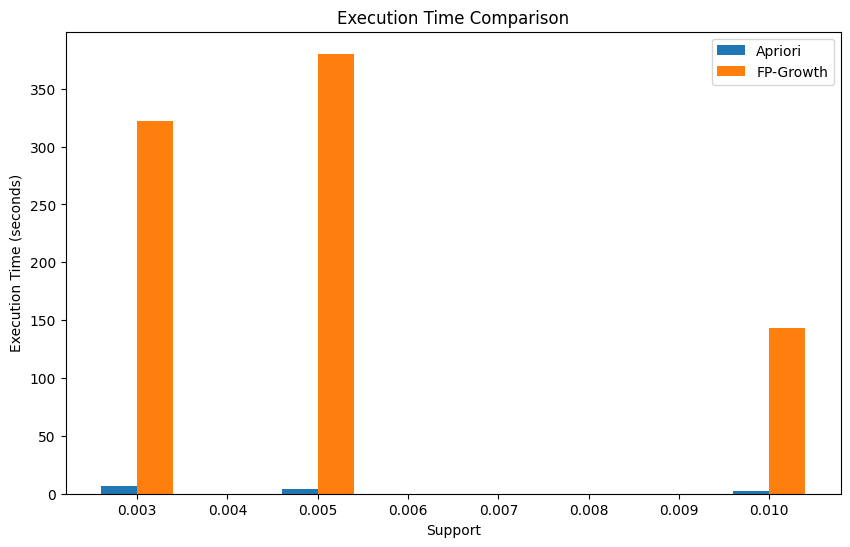

In [6]:
plt.figure(figsize=(10,6))
plt.bar(df_compare['support']-0.0002, df_compare['apriori_time'], width=0.0004, label='Apriori')
plt.bar(df_compare['support']+0.0002, df_compare['fpgrowth_time'], width=0.0004, label='FP-Growth')
plt.xlabel("Support")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison")
plt.legend()
plt.show()



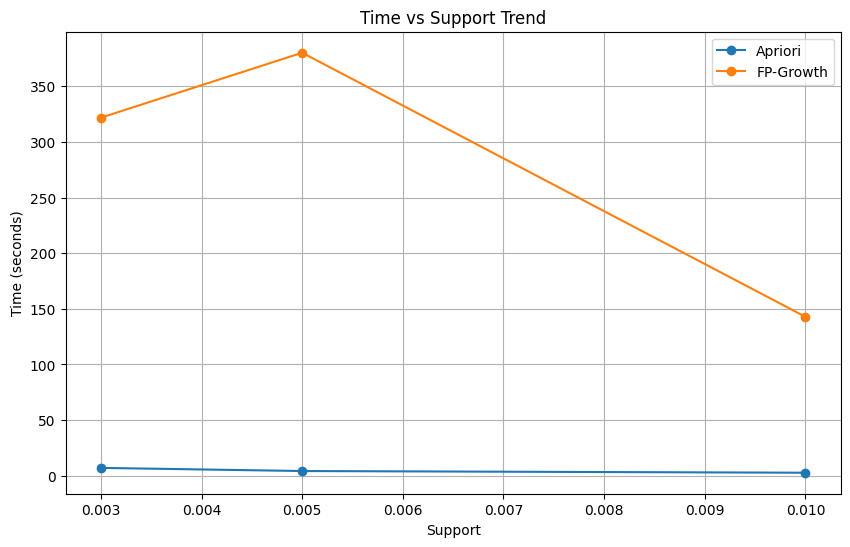

In [7]:
plt.figure(figsize=(10,6))
plt.plot(df_compare['support'], df_compare['apriori_time'], marker='o', label='Apriori')
plt.plot(df_compare['support'], df_compare['fpgrowth_time'], marker='o', label='FP-Growth')
plt.xlabel("Support")
plt.ylabel("Time (seconds)")
plt.title("Time vs Support Trend")
plt.legend()
plt.grid(True)
plt.show()


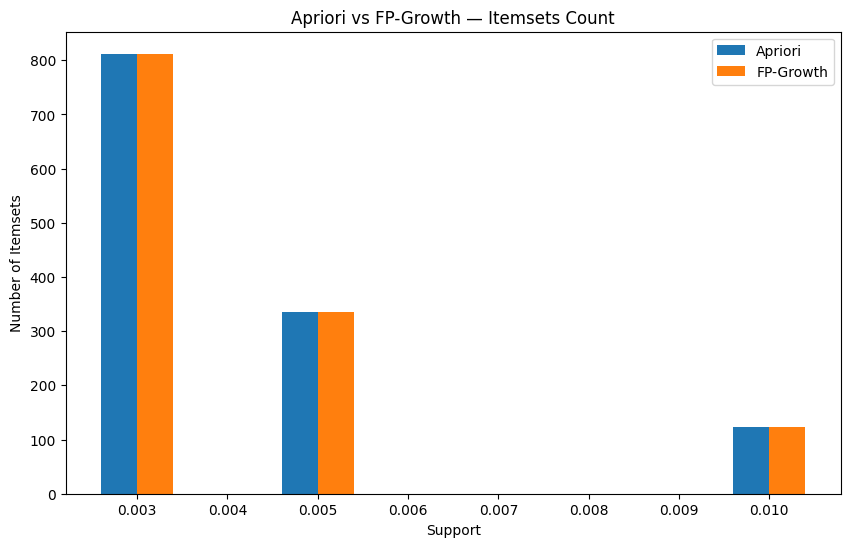

In [8]:
plt.figure(figsize=(10,6))
plt.bar(df_compare['support']-0.0002, df_compare['apriori_itemsets'], width=0.0004, label='Apriori')
plt.bar(df_compare['support']+0.0002, df_compare['fpgrowth_itemsets'], width=0.0004, label='FP-Growth')
plt.xlabel("Support")
plt.ylabel("Number of Itemsets")
plt.title("Apriori vs FP-Growth — Itemsets Count")
plt.legend()
plt.show()


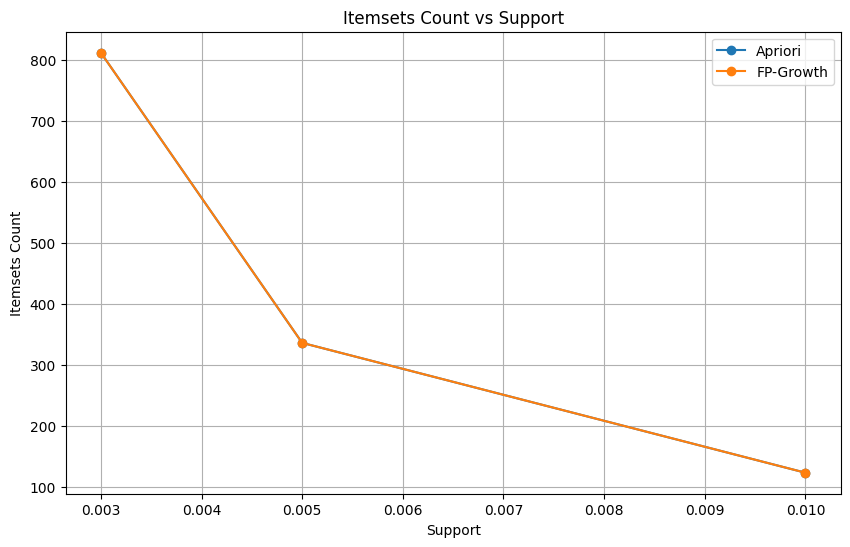

In [9]:

plt.figure(figsize=(10,6))
plt.plot(df_compare['support'], df_compare['apriori_itemsets'], marker='o', label='Apriori')
plt.plot(df_compare['support'], df_compare['fpgrowth_itemsets'], marker='o', label='FP-Growth')
plt.xlabel("Support")
plt.ylabel("Itemsets Count")
plt.title("Itemsets Count vs Support")
plt.legend()
plt.grid(True)
plt.show()


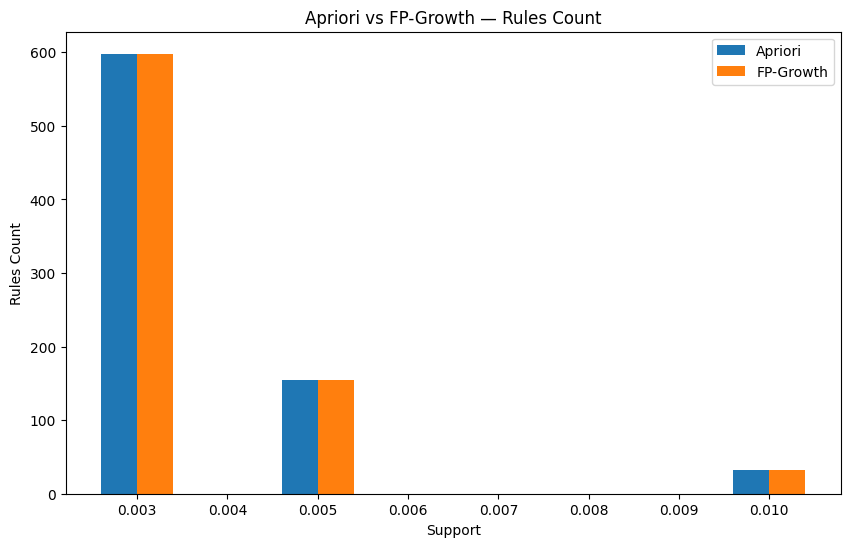

In [10]:
plt.figure(figsize=(10,6))
plt.bar(df_compare['support']-0.0002, df_compare['apriori_rules'], width=0.0004, label='Apriori')
plt.bar(df_compare['support']+0.0002, df_compare['fpgrowth_rules'], width=0.0004, label='FP-Growth')
plt.xlabel("Support")
plt.ylabel("Rules Count")
plt.title("Apriori vs FP-Growth — Rules Count")
plt.legend()
plt.show()



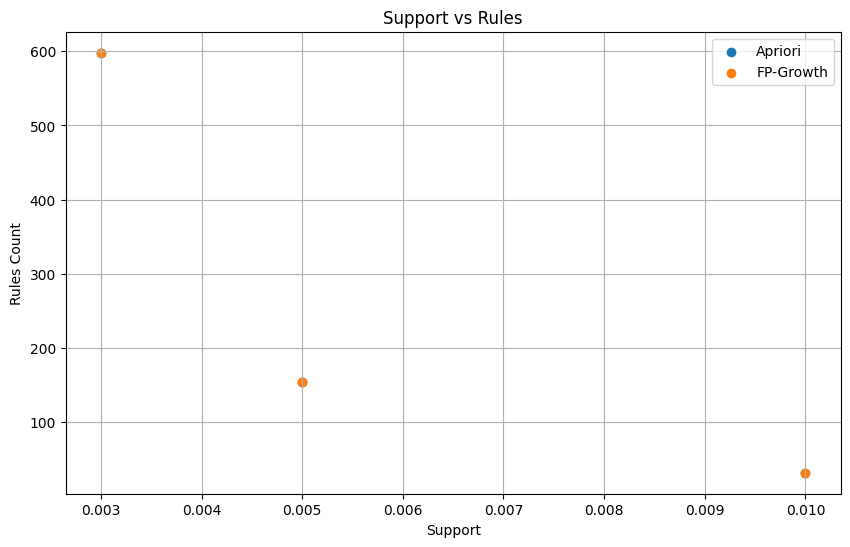

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(df_compare['support'], df_compare['apriori_rules'], label='Apriori')
plt.scatter(df_compare['support'], df_compare['fpgrowth_rules'], label='FP-Growth')
plt.xlabel("Support")
plt.ylabel("Rules Count")
plt.title("Support vs Rules")
plt.legend()
plt.grid(True)
plt.show()


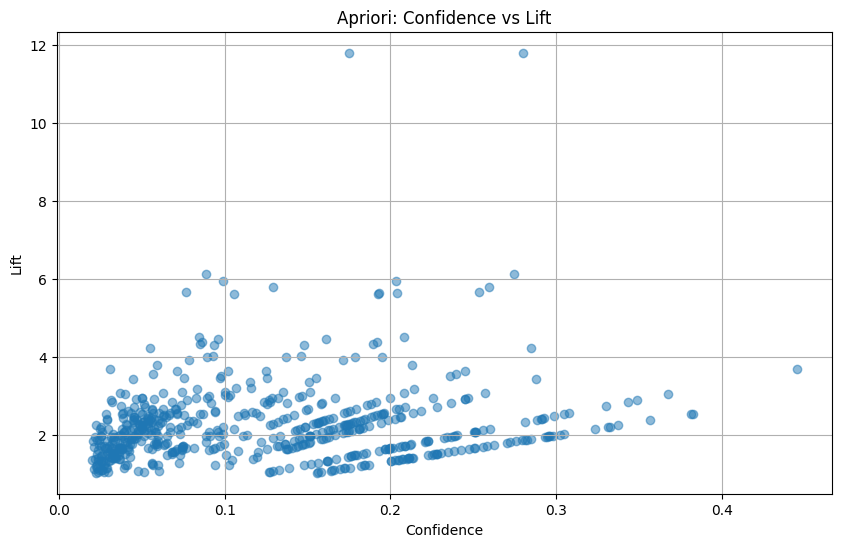

In [12]:

plt.figure(figsize=(10,6))
plt.scatter(ap_rules['confidence'], ap_rules['lift'], alpha=0.5)
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Apriori: Confidence vs Lift")
plt.grid(True)
plt.show()


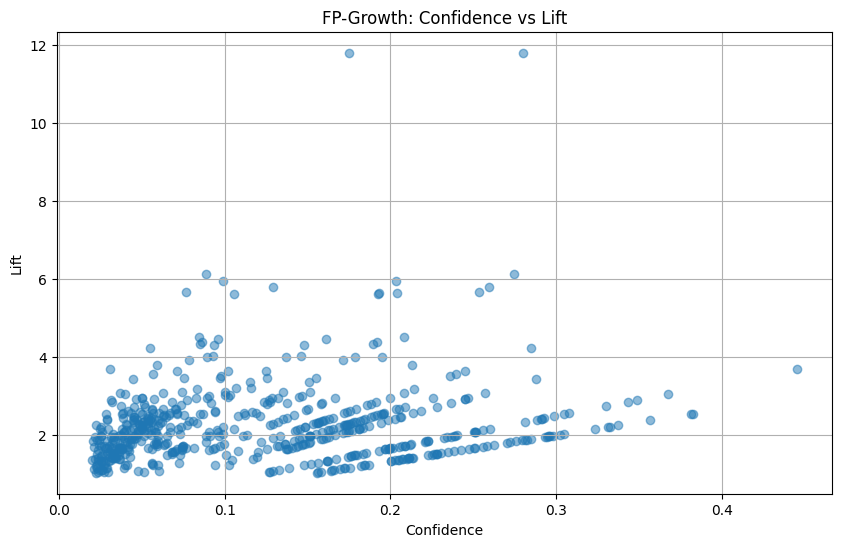

In [13]:
plt.figure(figsize=(10,6))
plt.scatter(fp_rules['confidence'], fp_rules['lift'], alpha=0.5)
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("FP-Growth: Confidence vs Lift")
plt.grid(True)
plt.show()


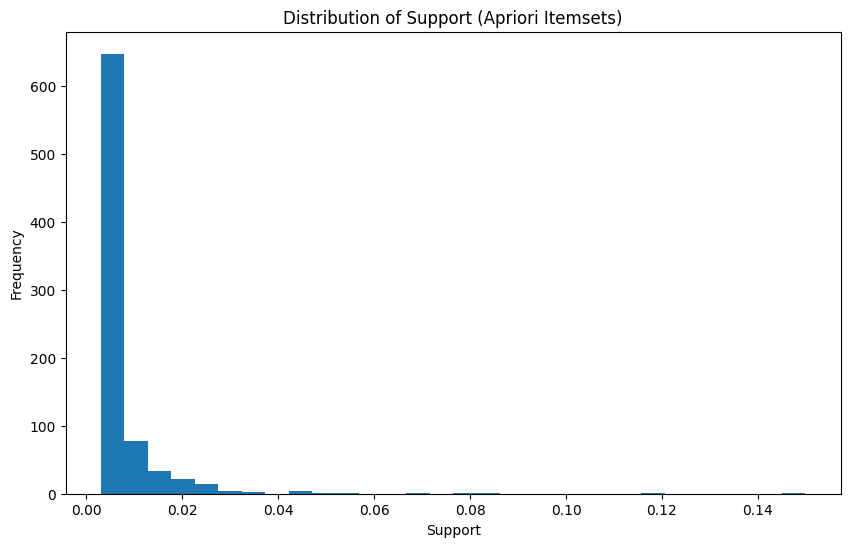

In [14]:
plt.figure(figsize=(10,6))
plt.hist(ap_it['support'], bins=30)
plt.xlabel("Support")
plt.ylabel("Frequency")
plt.title("Distribution of Support (Apriori Itemsets)")
plt.show()


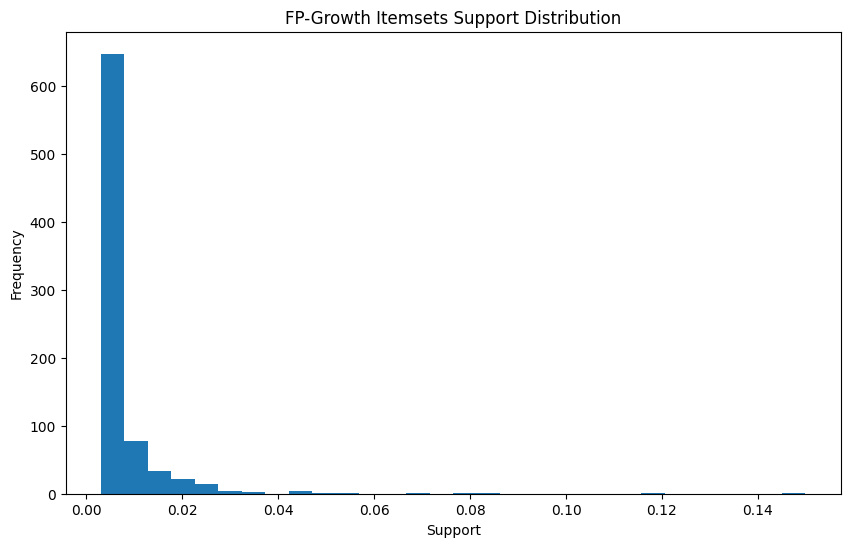

In [15]:
plt.figure(figsize=(10,6))
plt.hist(fp_it['support'], bins=30)
plt.xlabel("Support")
plt.ylabel("Frequency")
plt.title("FP-Growth Itemsets Support Distribution")
plt.show()


C:\Users\abhay\AppData\Local\Temp\ipykernel_13488\3623299988.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_compare['apriori_time'], df_compare['fpgrowth_time']], labels=['Apriori', 'FP-Growth'])


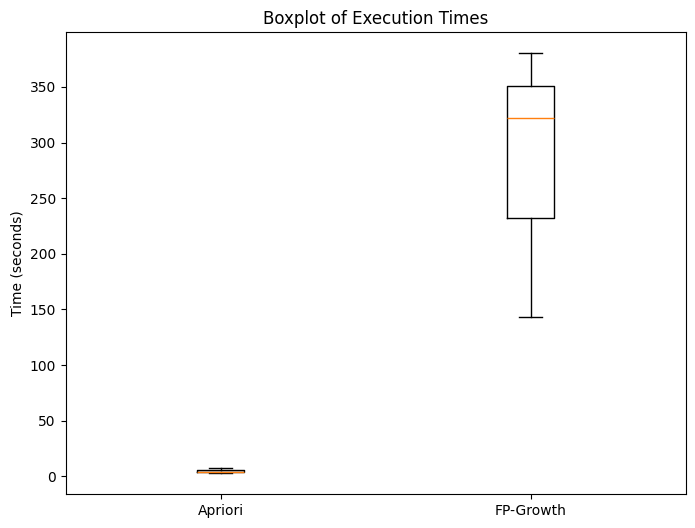

In [16]:
plt.figure(figsize=(8,6))
plt.boxplot([df_compare['apriori_time'], df_compare['fpgrowth_time']], labels=['Apriori', 'FP-Growth'])
plt.ylabel("Time (seconds)")
plt.title("Boxplot of Execution Times")
plt.show()


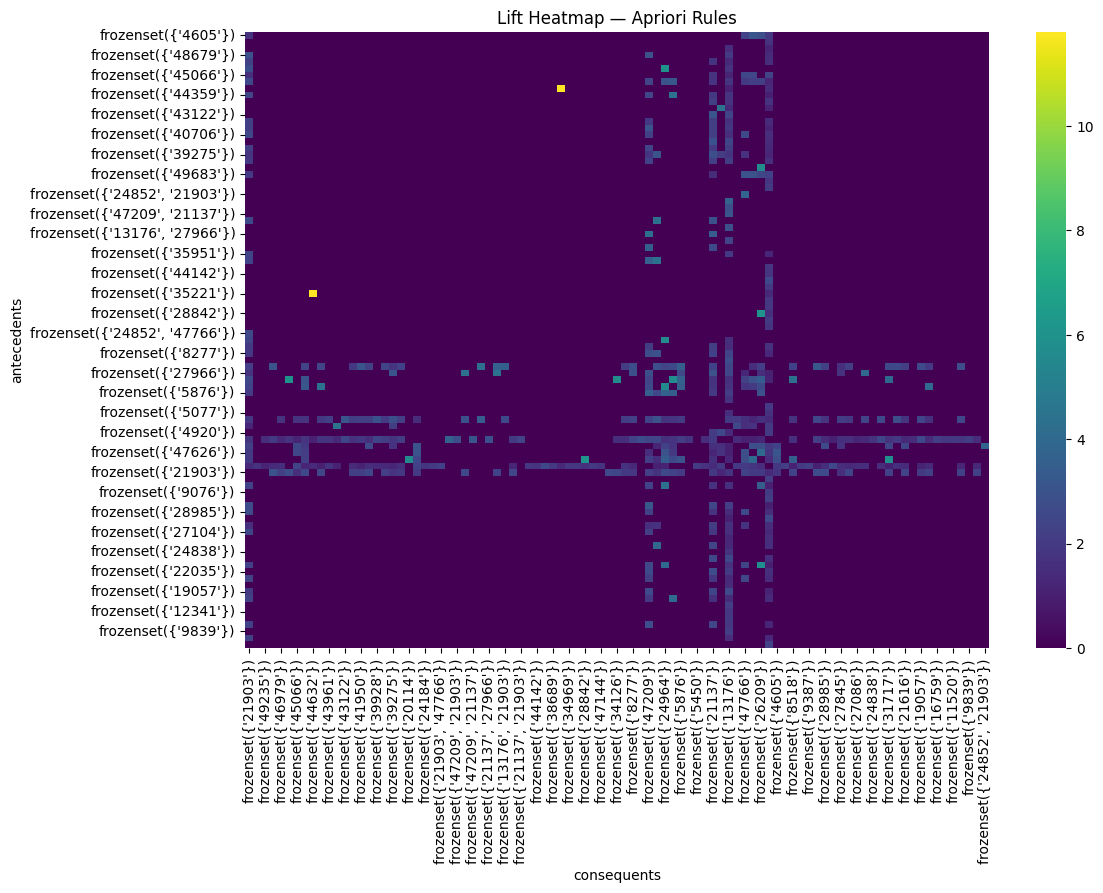

In [17]:
import seaborn as sns

temp = ap_rules.pivot_table(values='lift', index='antecedents', columns='consequents')
plt.figure(figsize=(12,8))
sns.heatmap(temp.fillna(0), cmap='viridis')
plt.title("Lift Heatmap — Apriori Rules")
plt.show()


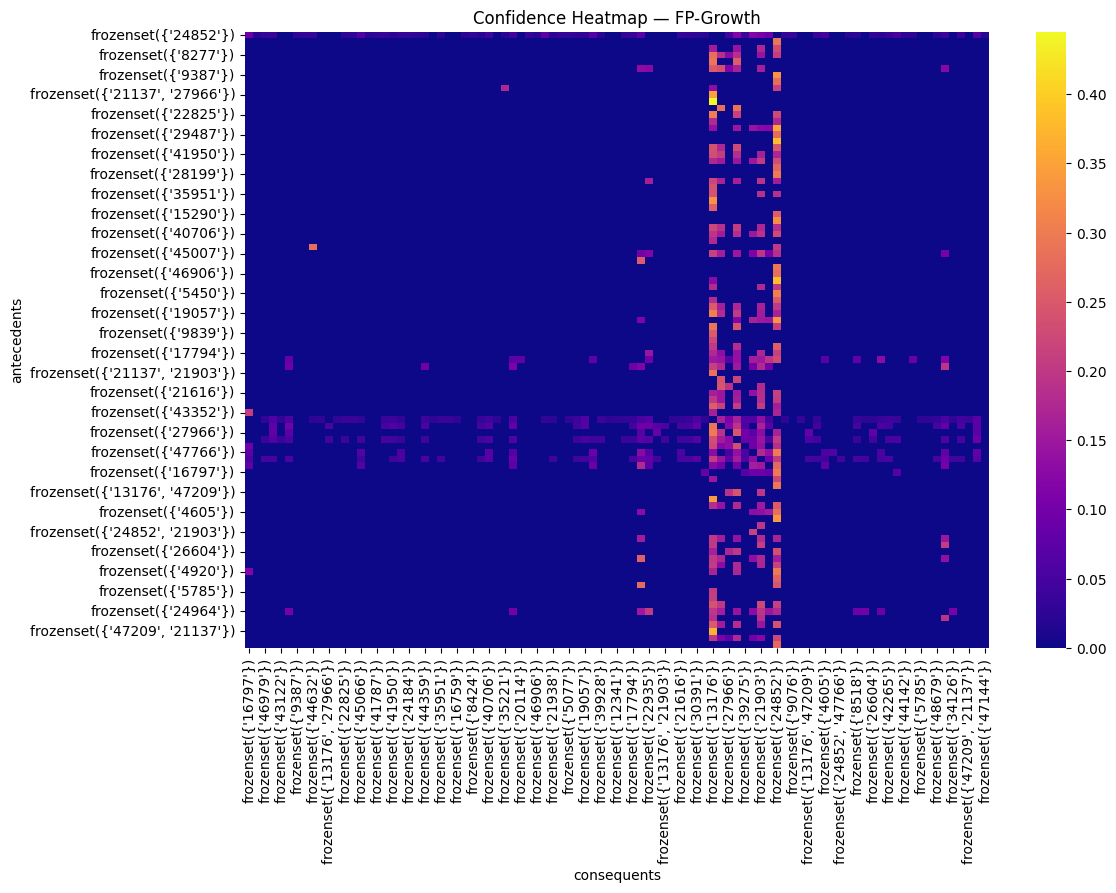

In [18]:
temp = fp_rules.pivot_table(values='confidence', index='antecedents', columns='consequents')
plt.figure(figsize=(12,8))
sns.heatmap(temp.fillna(0), cmap='plasma')
plt.title("Confidence Heatmap — FP-Growth")
plt.show()


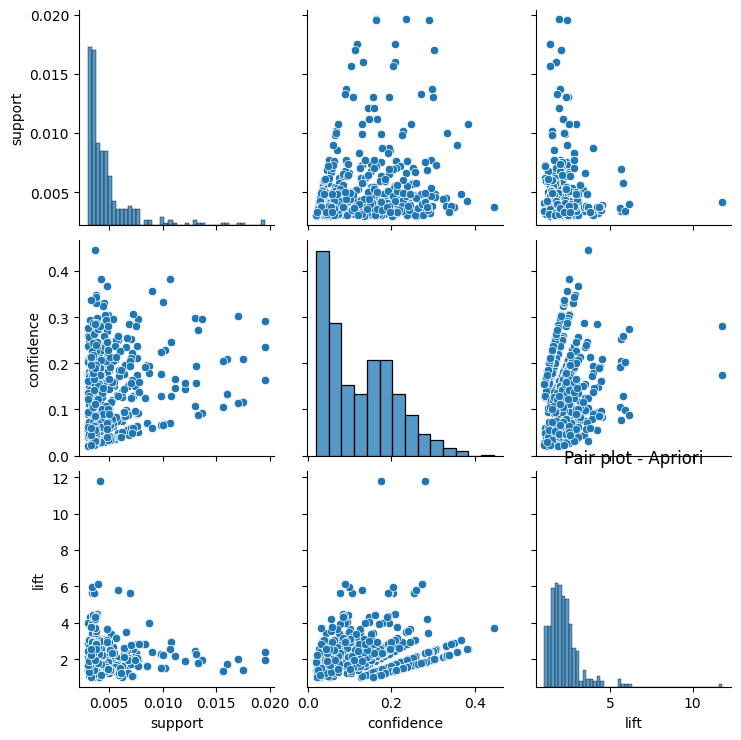

In [19]:
sns.pairplot(ap_rules[['support','confidence','lift']])
plt.title("Pair plot - Apriori")
plt.show()


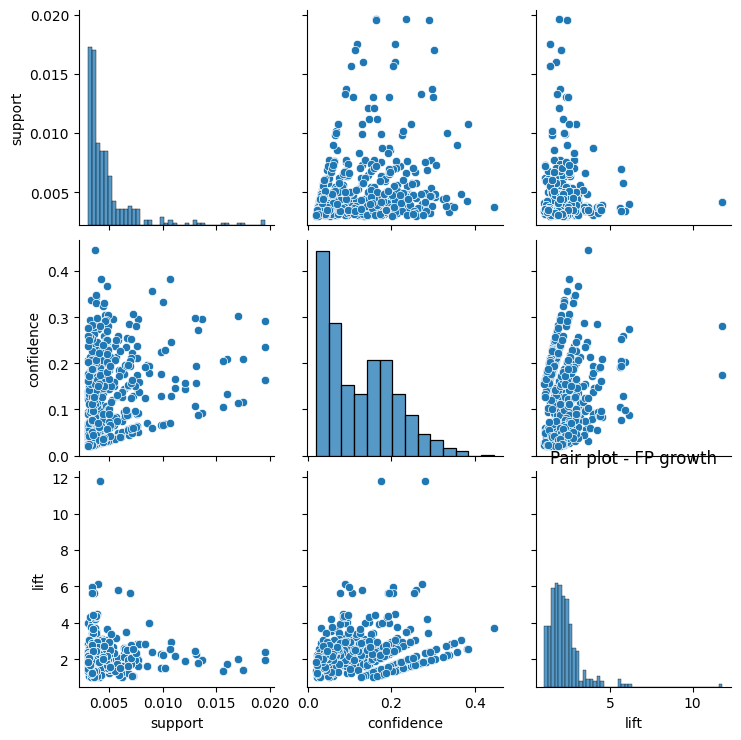

In [20]:
sns.pairplot(fp_rules[['support','confidence','lift']])
plt.title("Pair plot - FP growth")
plt.show()
